# FlashAttention: IO-Aware Attention - 실습 코드 2: FlashAttention Tiling 원리 구현 (NumPy)

- Tutorial ID: `expand-flash-attention`
- Tutorial: FlashAttention: IO-Aware Attention
- Section ID: `expand-flash-attention-code-2`
- Section: 실습 코드 2: FlashAttention Tiling 원리 구현 (NumPy)


In [1]:
# ============================================================
# 코드 읽는 법 — 실습 코드 2: FlashAttention Tiling 원리 구현 (NumPy)
#
# 이 노트북은 FlashAttention 논문의 핵심 아이디어인
# "Tiling(블록 단위 처리) + Online Softmax"를 NumPy만으로 한 줄씩
# 재현해보는 실습입니다. GPU 없이도 "왜 이렇게 계산 순서를 바꾸면
# 메모리를 크게 아낄 수 있는지"를 눈으로 직접 확인하는 것이 목표입니다.
#
# 학습 목표:
#   1) 표준 Attention이 왜 시퀀스 길이 N에 대해 O(N^2) 메모리를
#      필요로 하는지 작은 예시로 이해한다
#   2) softmax를 "전체를 한 번에" 계산하지 않고 "조금씩 나눠서
#      누적"하는 Online Softmax의 원리를 아주 작은 벡터로 손 검증한다
#   3) Online Softmax를 Q/K/V 블록 단위로 확장한 것이 바로
#      FlashAttention의 Tiling 알고리즘임을 코드로 확인한다
#   4) Tiling으로 얻은 결과가 표준 Attention과 '완전히 동일한 값'을
#      내는지 검증하고, 메모리·속도 측면에서 무엇이 좋아지고
#      무엇이 좋아지지 않는지까지 확인한다
#
# 읽는 순서 (위에서 아래로 순서대로 실행하세요):
#   1) 표준 Attention 복습 — 아주 작은 숫자로 shape과 값을 직접 확인
#   2) 표준 Attention의 메모리 문제 — N이 커지면 왜 못 쓰게 되는가
#   3) Online Softmax 원리 — 6개짜리 벡터를 손으로 쪼개서 검증
#   4) Online Softmax를 Attention(Q, K, V)으로 확장하는 다리 놓기
#   5) FlashAttention Tiling 전체 구현 + 아주 작은 예시로 블록별 추적
#   6) 원래 크기(N=256)에서 표준 Attention과 최종 비교 (정확도 + 메모리)
#   7) (중요) 이 NumPy 구현이 "느려질 수도 있는" 이유 — 메모리 vs 속도
#   8) 직접 값을 바꿔보며 실험하기
#
# 미리 알아두면 좋은 것:
#   - 이 노트북은 Q(Query)/K(Key)/V(Value)와 softmax를 사용하는
#     기본 Attention 공식  Attention(Q,K,V) = softmax(QK^T/sqrt(d))V
#     을 이미 알고 있다고 가정합니다. 낯설다면 이전 실습 코드를 먼저 보세요.
#
# 주의:
#   - 이 노트북의 목적은 "알고리즘이 수학적으로 옳다"는 것을 검증하는
#     것입니다. 실제 FlashAttention이 GPU에서 빠른 이유는 SRAM(빠른
#     메모리) ↔ HBM(느린 메모리) 사이의 데이터 이동(IO)을 줄이기
#     때문인데, 이는 CUDA/Triton 같은 GPU 커널 레벨에서 일어나는
#     일입니다. 순수 Python/NumPy 반복문으로는 이 IO 절감 효과를
#     "속도"로 체감할 수 없고, 오히려 반복문 오버헤드 때문에 더
#     느려 보일 수 있습니다 (7번 섹션에서 직접 확인합니다).
# ============================================================


## 0. 핵심 아이디어를 한 문장으로

> **"같은 답을, 한 번에 다 펼쳐놓지 않고, 조각조각 계산해서 더해도 얻을 수 있다."**

Attention의 계산 결과(출력 O) 자체는 바뀌지 않습니다. 다만 계산을
**"Q, K, V를 통째로 놓고 한 번에" 처리하지 않고, "작은 블록으로 잘라
순서대로 누적"** 하는 방식으로 바꿉니다. 그 결과 한 번에 메모리에
올라가는 데이터의 크기가 시퀀스 길이 N의 제곱(N²)이 아니라 N에
비례하는 수준으로 줄어듭니다.

이 노트북은 이 문장이 실제로 코드에서 어떻게 성립하는지 아래 순서로
직접 확인합니다.

1. 표준 Attention은 얼마나 메모리를 쓰는가?
2. "부분적으로만 본 데이터"로 softmax를 정확히 계산하려면 어떻게 해야
   하는가? → **Online Softmax**
3. Online Softmax를 Q/K/V 블록에 그대로 적용하면? → **FlashAttention
   Tiling**


## 1. 표준(Standard) Attention 복습

FlashAttention을 이해하려면 먼저 "우리가 바꾸려는 대상"인 표준
Attention 계산을 손에 잡히는 작은 숫자로 다시 확인하고 넘어가야
합니다. 공식은 다음과 같습니다 (코드에서 쓸 표기와 맞췄습니다).

    Attention(Q, K, V) = softmax( Q @ K.T / sqrt(d) ) @ V

- **Q (Query)**: "내가 지금 무엇을 찾고 있는가"를 나타내는 벡터들, shape `(N, d)`
- **K (Key)**: "각 위치가 어떤 정보를 갖고 있는가"를 나타내는 벡터들, shape `(N, d)`
- **V (Value)**: "각 위치가 실제로 전달할 값", shape `(N, d)`
- **N**: 시퀀스 길이(토큰 개수), **d**: 각 벡터의 차원

아래에서는 N=4(토큰 4개), d=3(차원 3)짜리 아주 작은 예시를 만들어
Q, K, V → 점수(S) → softmax 가중치 → 최종 출력까지 각 단계의 shape와
실제 값을 전부 눈으로 확인합니다.


In [2]:
import numpy as np

# ── 아주 작은 예시로 Attention을 손으로 따라가 봅니다 ──
# N=4: 토큰(단어)이 4개, d=3: 각 토큰을 표현하는 벡터의 차원이 3
#
# 실제로는 Q, K, V가 학습된 가중치 행렬을 통해 만들어지지만, 여기서는
# "어떤 값이 들어와도 계산 흐름은 같다"는 것을 직접 보기 위해 값을
# 0과 1로만 이루어지도록 손으로 지정했습니다. 이렇게 하면 어떤
# 토큰이 어떤 키(key)와 잘 맞는지 점수만 보고도 짐작할 수 있습니다.
Q = np.array([
    [1.0, 0.0, 0.0],   # 토큰 0
    [0.0, 1.0, 0.0],   # 토큰 1
    [0.0, 0.0, 1.0],   # 토큰 2
    [1.0, 1.0, 0.0],   # 토큰 3
])

K = np.array([
    [1.0, 0.0, 0.0],   # 키 0
    [0.0, 1.0, 0.0],   # 키 1
    [0.0, 0.0, 1.0],   # 키 2
    [0.0, 1.0, 1.0],   # 키 3
])

V = np.array([
    [1.0, 0.0, 0.0],   # 키 0 위치가 실제로 전달할 값
    [0.0, 1.0, 0.0],   # 키 1 위치가 전달할 값
    [0.0, 0.0, 1.0],   # 키 2 위치가 전달할 값
    [1.0, 1.0, 1.0],   # 키 3 위치가 전달할 값
])

N, d = Q.shape
print(f"N(시퀀스 길이) = {N}, d(차원) = {d}")
print(f"Q shape = {Q.shape}, K shape = {K.shape}, V shape = {V.shape}")

# ── 1단계: 점수(score) 계산  S = Q @ K.T / sqrt(d) ──
# Q@K.T의 (i, j) 원소는 "토큰 i가 키 j를 얼마나 주목하는가"를 나타내는 날것 점수
# shape 변화: (N, d) @ (d, N) -> (N, N)
scale = np.sqrt(d)
S = Q @ K.T / scale
print("\n[1단계] 점수 행렬 S = Q @ K.T / sqrt(d)")
print(f"  shape: {Q.shape} @ {K.T.shape} -> {S.shape}")
print(S.round(3))

# ── 2단계: 각 행에 softmax를 적용해 '가중치(확률분포)'로 변환 ──
# 수치적으로 안정적인 softmax: 각 행의 최댓값을 뺀 뒤 지수함수를 취함
# (이렇게 하지 않으면 값이 클 때 exp(x)가 오버플로될 수 있음)
S_max = S.max(axis=-1, keepdims=True)               # 행별 최댓값, shape (N, 1)
exp_S = np.exp(S - S_max)                            # shape (N, N)
weights = exp_S / exp_S.sum(axis=-1, keepdims=True)  # 행별 합이 1이 되도록 정규화
print("\n[2단계] softmax 가중치 (각 행의 합은 항상 1)")
print(weights.round(3))
print("  행별 합 확인:", weights.sum(axis=-1).round(6))

# 어떤 토큰이 어떤 키에 가장 큰 가중치를 주는지 직접 계산해서 확인
most_attended = weights.argmax(axis=-1)
print("\n  → 각 토큰이 가장 크게 주목하는 키:")
for i in range(N):
    j = most_attended[i]
    print(f"     토큰 {i} -> 키 {j}  (가중치 {weights[i, j]:.3f})")

# ── 3단계: 가중치로 V를 가중합 -> 최종 출력 ──
# shape 변화: (N, N) @ (N, d) -> (N, d)
O_manual = weights @ V
print("\n[3단계] 최종 출력 O = weights @ V")
print(f"  shape: {weights.shape} @ {V.shape} -> {O_manual.shape}")
print(O_manual.round(3))
print("\n  → 각 토큰의 출력은, 그 토큰이 높은 가중치를 준 키들의 V값이")
print("    섞여서 만들어진 결과입니다. weights 행렬을 보면 어느 V가")
print("    얼마나 섞였는지 그대로 알 수 있습니다.")


N(시퀀스 길이) = 4, d(차원) = 3
Q shape = (4, 3), K shape = (4, 3), V shape = (4, 3)

[1단계] 점수 행렬 S = Q @ K.T / sqrt(d)
  shape: (4, 3) @ (3, 4) -> (4, 4)
[[0.577 0.    0.    0.   ]
 [0.    0.577 0.    0.577]
 [0.    0.    0.577 0.577]
 [0.577 0.577 0.    0.577]]

[2단계] softmax 가중치 (각 행의 합은 항상 1)
[[0.373 0.209 0.209 0.209]
 [0.18  0.32  0.18  0.32 ]
 [0.18  0.18  0.32  0.32 ]
 [0.281 0.281 0.158 0.281]]
  행별 합 확인: [1. 1. 1. 1.]

  → 각 토큰이 가장 크게 주목하는 키:
     토큰 0 -> 키 0  (가중치 0.373)
     토큰 1 -> 키 1  (가중치 0.320)
     토큰 2 -> 키 2  (가중치 0.320)
     토큰 3 -> 키 0  (가중치 0.281)

[3단계] 최종 출력 O = weights @ V
  shape: (4, 4) @ (4, 3) -> (4, 3)
[[0.582 0.418 0.418]
 [0.5   0.64  0.5  ]
 [0.5   0.5   0.64 ]
 [0.562 0.562 0.438]]

  → 각 토큰의 출력은, 그 토큰이 높은 가중치를 준 키들의 V값이
    섞여서 만들어진 결과입니다. weights 행렬을 보면 어느 V가
    얼마나 섞였는지 그대로 알 수 있습니다.


In [3]:
# ── 위에서 손으로 진행한 3단계를 함수로 정리합니다 ──
# 이 함수는 앞으로 "정답(ground truth)"으로 계속 사용됩니다. FlashAttention
# Tiling이 맞게 구현됐는지 확인할 때, 항상 이 함수의 결과와 비교할 것입니다.
def standard_attention(Q, K, V):
    """표준 Attention. 메모리를 O(N^2)만큼 사용합니다.

    Parameters
    ----------
    Q, K, V : np.ndarray, shape (N, d)

    Returns
    -------
    np.ndarray, shape (N, d)
    """
    d = Q.shape[-1]

    # (N, d) @ (d, N) -> (N, N)  ← 바로 이 (N, N) 크기의 행렬이
    # FlashAttention이 "절대 통째로 만들지 않으려는" 대상입니다.
    scores = Q @ K.T / np.sqrt(d)

    # 수치적으로 안정적인 softmax (행별 최댓값을 뺀 뒤 지수함수)
    scores_max = scores.max(axis=-1, keepdims=True)
    exp_scores = np.exp(scores - scores_max)
    weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True)  # (N, N)

    return weights @ V  # (N, N) @ (N, d) -> (N, d)


# 함수가 위에서 손으로 계산한 것과 완전히 같은 값을 주는지 확인
O_function = standard_attention(Q, K, V)
same = np.allclose(O_manual, O_function)
print(f"손으로 계산한 결과와 함수 결과가 같은가? -> {same}")
print(O_function.round(3))


손으로 계산한 결과와 함수 결과가 같은가? -> True
[[0.582 0.418 0.418]
 [0.5   0.64  0.5  ]
 [0.5   0.5   0.64 ]
 [0.562 0.562 0.438]]


## 2. 표준 Attention의 진짜 문제: 메모리

위에서 만든 점수 행렬 `S`의 shape은 `(N, N)`이었습니다. N=4일 때는
원소가 16개뿐이라 아무 문제가 없었습니다. 그런데 실제 LLM에서
시퀀스 길이 N은 수천 ~ 수십만까지 커집니다.

**`S`의 원소 개수는 N²에 비례합니다.** N이 10배 늘어나면 `S`가
차지하는 메모리는 100배로 늘어납니다. 게다가 softmax 계산 중에는
`scores`, `exp_scores`, `weights`처럼 `(N, N)` 크기 배열이 동시에
여러 개 존재할 수도 있습니다.

아래 코드에서 N을 늘려가며 `S` 한 장(float64 기준)이 실제로 몇 MB,
몇 GB가 되는지 직접 계산해봅니다.


In [4]:
# ── N이 커질수록 (N, N) 점수 행렬이 얼마나 무거워지는지 계산 ──
BYTES_PER_FLOAT64 = 8  # np.float64 하나 = 8바이트

seq_lengths = [128, 512, 2_048, 8_192, 32_768, 131_072]

print(f"{'N (시퀀스 길이)':>16} | {'(N,N) 원소 개수':>18} | {'필요 메모리':>14}")
print("-" * 56)
for N_test in seq_lengths:
    n_elements = N_test * N_test
    n_bytes = n_elements * BYTES_PER_FLOAT64
    # 사람이 읽기 편한 단위(MB 또는 GB)로 변환
    if n_bytes < 1e9:
        size_str = f"{n_bytes / 1e6:8.1f} MB"
    else:
        size_str = f"{n_bytes / 1e9:8.1f} GB"
    print(f"{N_test:>16,} | {n_elements:>18,} | {size_str:>14}")

print("\n→ 점수 행렬 '한 장'만 이 정도입니다. 실제 학습/추론에서는 여러")
print("  attention head, 여러 layer, 여러 배치가 동시에 존재하므로 실제")
print("  필요 메모리는 이보다 훨씬 더 큽니다.")


      N (시퀀스 길이) |        (N,N) 원소 개수 |         필요 메모리
--------------------------------------------------------
             128 |             16,384 |         0.1 MB
             512 |            262,144 |         2.1 MB
           2,048 |          4,194,304 |        33.6 MB
           8,192 |         67,108,864 |       536.9 MB
          32,768 |      1,073,741,824 |         8.6 GB
         131,072 |     17,179,869,184 |       137.4 GB

→ 점수 행렬 '한 장'만 이 정도입니다. 실제 학습/추론에서는 여러
  attention head, 여러 layer, 여러 배치가 동시에 존재하므로 실제
  필요 메모리는 이보다 훨씬 더 큽니다.


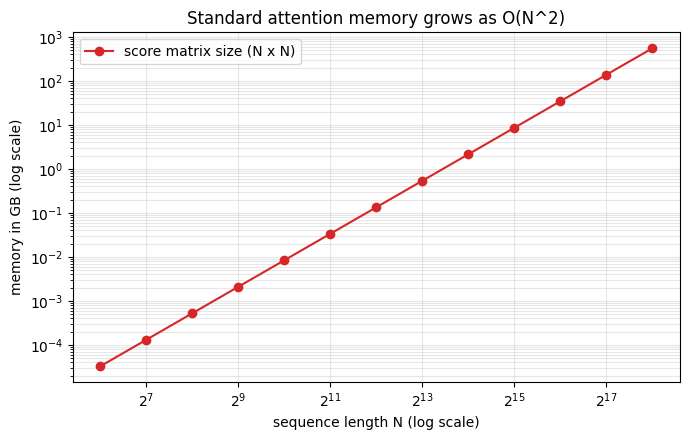

직선이 아니라 로그-로그 축에서도 가파르게 꺾여 올라가는 것이 보이나요?
N이 늘어날수록 메모리 요구량이 '제곱' 속도로 증가한다는 뜻입니다.


In [5]:
import matplotlib.pyplot as plt

# 더 촘촘한 N 범위로 그래프를 그려 N^2으로 폭발하는 모습을 확인합니다.
# (그림 안의 글자는 노트북 실행 환경마다 한글 폰트가 다를 수 있어
#  호환을 위해 영어로 표기했습니다. 의미는 위 표와 아래 설명으로
#  충분히 알 수 있습니다.)
N_range = np.array([2 ** k for k in range(6, 19)])   # 64 ~ 262144
standard_bytes = N_range.astype(np.float64) ** 2 * BYTES_PER_FLOAT64

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(N_range, standard_bytes / 1e9, marker="o", color="#d62728",
        label="score matrix size (N x N)")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("sequence length N (log scale)")
ax.set_ylabel("memory in GB (log scale)")
ax.set_title("Standard attention memory grows as O(N^2)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("직선이 아니라 로그-로그 축에서도 가파르게 꺾여 올라가는 것이 보이나요?")
print("N이 늘어날수록 메모리 요구량이 '제곱' 속도로 증가한다는 뜻입니다.")


## 3. 해결의 실마리: Online(점진적) Softmax

FlashAttention의 핵심 트릭은 **"전체 점수를 다 모으지 않고도 정확한
softmax를 계산하는 방법"** 입니다. 이것만 이해하면 나머지는 이
아이디어를 Q/K/V 블록에 적용하는 것뿐입니다.

**왜 어려운가?** softmax는 다음과 같이 정의됩니다.

    softmax(x)_i = exp(x_i - m) / sum_k exp(x_k - m),   m = max_k(x_k)

문제는 분모(합)와 `m`(최댓값) 모두 **데이터 전체를 봐야 계산할 수
있다**는 점입니다. 데이터를 앞부분, 뒷부분으로 나눠서 본다면?
뒷부분에서 더 큰 값이 나오는 순간, 앞부분에서 이미 계산해 둔 값들의
기준(m)이 전부 바뀌어야 합니다.

**Online Softmax의 해법:** "지금까지 본 것 중 최댓값(m)"과 "지금까지
본 것들의 합(l, m 기준으로 정규화된 값)"을 계속 들고 다니다가, 새
조각을 볼 때마다 다음 3단계를 반복합니다.

1. 새 조각의 최댓값과 지금까지의 최댓값 중 더 큰 값을 새 기준(`m_new`)으로 정한다
2. 지금까지의 합(`l`)을 새 기준에 맞게 다시 스케일한다: `l * exp(m_old - m_new)`
3. 새 조각의 합을 새 기준으로 계산해서 더한다

기준이 바뀔 때마다 "이전 결과를 새 기준으로 다시 눈금 조정"하는 것이
전부입니다. 정말 이렇게 해도 정확히 같은 값이 나오는지, 6개짜리
벡터 하나로 직접 확인해봅시다.


In [6]:
# ── Online Softmax를 6개짜리 벡터 하나로 손 검증 ──
x = np.array([2.0, 1.0, 4.0, 0.5, 5.0, -1.0])
print("전체 벡터 x:", x)

# (A) 표준 방식: x 전체를 한 번에 보고 softmax 계산
m_true = x.max()
l_true = np.exp(x - m_true).sum()
softmax_true = np.exp(x - m_true) / l_true
print(f"\n[표준 방식] 전체를 한 번에 봤을 때")
print(f"  최댓값 m = {m_true}")
print(f"  분모   l = {l_true:.6f}")
print(f"  softmax = {softmax_true.round(4)}")

# (B) Online 방식: x를 앞/뒤 두 조각으로 나눠서, "부분만 보고" 계산
chunk1 = x[:3]   # 앞부분만 먼저 도착했다고 가정
chunk2 = x[3:]   # 뒷부분은 나중에 도착
print(f"\n[Online 방식] 두 조각으로 나눠서 처리: chunk1={chunk1}, chunk2={chunk2}")

# 초기 상태: 아직 아무것도 못 봤으므로 최댓값은 -무한대, 합은 0
m = -np.inf
l = 0.0

for step, chunk in enumerate([chunk1, chunk2], start=1):
    m_chunk = chunk.max()                 # 이번 조각만의 최댓값
    m_new = max(m, m_chunk)               # 지금까지 vs 이번 조각, 더 큰 값이 새 기준

    # 이전까지의 합을 새 기준(m_new)에 맞게 다시 스케일링
    # (m이 -inf였던 첫 스텝에서는 exp(-inf - 유한수) = 0 이 되어 자연스럽게 무시됨)
    l_rescaled = l * np.exp(m - m_new)

    # 이번 조각의 합을 "새 기준" 위에서 계산
    p_chunk = np.exp(chunk - m_new)
    l_new = l_rescaled + p_chunk.sum()

    print(f"  step {step}: 이번 조각 최댓값={m_chunk:.3f} -> 새 기준 m={m_new:.3f}, "
          f"이전 합 재조정={l_rescaled:.6f}, 이번 조각 합={p_chunk.sum():.6f}, "
          f"누적 합 l={l_new:.6f}")

    m, l = m_new, l_new

print(f"\n최종 Online 결과: m={m}, l={l:.6f}")
print(f"표준 방식 결과   : m={m_true}, l={l_true:.6f}")
print(f"두 결과가 같은가? -> {np.isclose(l, l_true) and np.isclose(m, m_true)}")


전체 벡터 x: [ 2.   1.   4.   0.5  5.  -1. ]

[표준 방식] 전체를 한 번에 봤을 때
  최댓값 m = 5.0
  분모   l = 1.449570
  softmax = [0.0343 0.0126 0.2538 0.0077 0.6899 0.0017]

[Online 방식] 두 조각으로 나눠서 처리: chunk1=[2. 1. 4.], chunk2=[ 0.5  5.  -1. ]
  step 1: 이번 조각 최댓값=4.000 -> 새 기준 m=4.000, 이전 합 재조정=0.000000, 이번 조각 합=1.185122, 누적 합 l=1.185122
  step 2: 이번 조각 최댓값=5.000 -> 새 기준 m=5.000, 이전 합 재조정=0.435982, 이번 조각 합=1.013588, 누적 합 l=1.449570

최종 Online 결과: m=5.0, l=1.449570
표준 방식 결과   : m=5.0, l=1.449570
두 결과가 같은가? -> True


분모(정규화 상수)는 조각조각 계산해도 똑같은 값이 나온다는 것을
확인했습니다. 그런데 Attention에서 진짜로 필요한 결과는 softmax
가중치 자체가 아니라 **"가중치로 V를 가중합한 값"** 입니다.

다행히 원리는 완전히 같습니다. `l`뿐만 아니라 **"지금까지의 출력
O"도 같은 방식으로 새 기준에 맞춰 재조정**해주면 됩니다. 이번에는
x의 각 원소마다 대응하는 값(v)을 하나씩 붙여서, "가중합 출력"까지
Online으로 정확히 계산되는지 확인해봅시다.


In [7]:
# ── 이번엔 x의 각 원소에 '값(v)'을 하나씩 붙여서 가중합까지 계산 ──
x = np.array([2.0, 1.0, 4.0, 0.5, 5.0, -1.0])
v = np.array([10.0, 20.0, 30.0, 40.0, 50.0, 60.0])   # 각 x에 대응하는 값
print("x:", x)
print("v:", v)

# (A) 표준 방식: softmax(x) 가중치로 v를 가중합
m_true = x.max()
weights_true = np.exp(x - m_true) / np.exp(x - m_true).sum()
O_true = (weights_true * v).sum()
print(f"\n[표준 방식] 가중합 출력 O = {O_true:.6f}")

# (B) Online 방식: chunk 단위로 m, l 뿐만 아니라 O까지 누적
chunk_x = [x[:3], x[3:]]
chunk_v = [v[:3], v[3:]]

m, l, O = -np.inf, 0.0, 0.0   # O도 m, l과 함께 관리되는 '상태'

for step, (cx, cv) in enumerate(zip(chunk_x, chunk_v), start=1):
    m_chunk = cx.max()
    m_new = max(m, m_chunk)

    l_rescaled = l * np.exp(m - m_new)          # 이전 분모를 새 기준으로 재조정 (앞과 동일)
    p_chunk = np.exp(cx - m_new)                # 이번 조각의 분자값 (새 기준)
    l_new = l_rescaled + p_chunk.sum()          # 새로운 전체 분모

    # ↓↓↓ 여기가 새로 추가된 부분: 출력 O도 같은 방식으로 재조정 ↓↓↓
    # 나중에 볼 flash_attention_tiled() 함수와 완전히 같은 패턴입니다.
    #   1) 이전 출력을 (재조정된 이전 분모 / 새 분모) 비율로 눈금 조정
    #   2) 이번 조각의 기여분을 (새 분모)로 나눠서 더함
    O_old_term = O * l_rescaled / l_new          # 이전 출력 기여분 (새 기준)
    O_new_term = (p_chunk * cv).sum() / l_new    # 이번 조각 기여분 (새 기준)
    O = O_old_term + O_new_term

    print(f"  step {step}: m={m_new:.3f}  l={l_new:.6f}  O(누적)={O:.6f}")

    m, l = m_new, l_new

print(f"\n최종 Online 결과: O = {O:.6f}")
print(f"표준 방식 결과   : O = {O_true:.6f}")
print(f"두 결과가 같은가? -> {np.isclose(O, O_true)}")


x: [ 2.   1.   4.   0.5  5.  -1. ]
v: [10. 20. 30. 40. 50. 60.]

[표준 방식] 가중합 출력 O = 43.111858
  step 1: m=4.000  l=1.185122  O(누적)=27.295995
  step 2: m=5.000  l=1.449570  O(누적)=43.111858

최종 Online 결과: O = 43.111858
표준 방식 결과   : O = 43.111858
두 결과가 같은가? -> True


## 4. 이제 진짜 FlashAttention: Q/K/V를 블록으로 쪼개기

방금 확인한 건 **숫자 하나짜리(스칼라) x와 v**에 대한 Online
Softmax였습니다. FlashAttention은 이 원리를 그대로 가져다가, 스칼라
하나 대신 **Q의 한 "블록"(여러 행), K·V의 한 "블록"** 단위로
적용합니다.

- `x` 하나 → `Q_block @ K_block.T` (여러 쿼리 × 여러 키의 점수 블록)
- `v` 하나 → `V_block` (여러 값 벡터)
- 스칼라 `m, l, O` → 각 쿼리 행(row)마다 하나씩 있는 벡터 `m, l, O`

**루프 구조**는 다음과 같습니다 (FlashAttention 논문 표기를 따름).

- **바깥 루프 (j)**: K, V를 블록 단위로 순회
- **안쪽 루프 (i)**: Q를 블록 단위로 순회하며, 같은 K_block/V_block에
  대해 Online 갱신을 수행

바깥 루프를 K/V 기준으로 도는 이유는, 실제 GPU 구현에서 K_block과
V_block을 한 번 SRAM에 올려두면 그 안쪽에서 여러 Q_block이 이를
재사용할 수 있어 데이터 이동(IO)이 줄어들기 때문입니다. (NumPy에서는
이 IO 절감이 속도로 드러나지는 않지만, 계산 순서 자체는 논문과
동일하게 맞춰봅니다.)

아래 그림은 N=12, block_size=3일 때 전체 (N, N) 점수 행렬이 어떻게
4×4개의 작은 블록으로 나뉘는지, 그리고 한 시점에는 그 중 "딱 한
블록"만 계산 대상이 된다는 것을 보여줍니다.


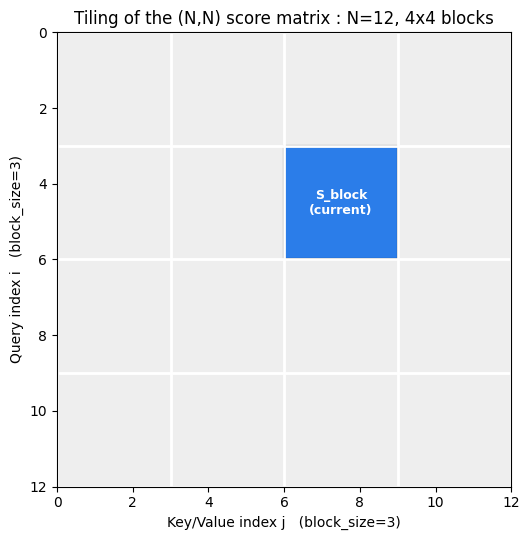

전체 12x12=144칸 중, 한 시점에 다루는 건
단 하나의 3x3=9칸짜리 블록뿐입니다.
나머지 회색 영역은 아직 계산되지 않았거나, 이미 계산 후 다음 통계값으로
녹아 들어가 더 이상 통째로 들고 있을 필요가 없는 상태입니다.


In [8]:
# ── (참고) Tiling 구조를 그림으로 확인하기 ──
# 실제 계산을 하는 코드가 아니라, "전체 (N,N) 점수 행렬이 블록으로
# 어떻게 나뉘는지"와 "한 시점엔 딱 한 블록만 다루면 된다"는 것을
# 시각적으로 보여주기 위한 그림입니다. (그림 속 글자는 폰트 호환을
# 위해 영어로 표기했습니다.)
N_demo, block_demo = 12, 3
n_blocks_demo = N_demo // block_demo

fig, ax = plt.subplots(figsize=(5.5, 5.5))

# 전체 (N, N) 영역: "존재는 하지만 한 번에 다 안 씀"을 나타내는 옅은 배경
ax.add_patch(plt.Rectangle((0, 0), N_demo, N_demo, facecolor="#eeeeee", edgecolor="none"))

# 블록 경계선을 그려 타일 구조를 표시
for k in range(0, N_demo + 1, block_demo):
    ax.axhline(k, color="white", linewidth=2)
    ax.axvline(k, color="white", linewidth=2)

# "지금 계산 중인 블록" 하나만 색칠해서 강조
cur_i, cur_j = 1, 2   # 예시로 고른 블록 위치 (i번째 Q블록, j번째 K/V블록)
ax.add_patch(plt.Rectangle((cur_j * block_demo, cur_i * block_demo),
                            block_demo, block_demo,
                            facecolor="#2b7de9", edgecolor="black", linewidth=1.5))
ax.text(cur_j * block_demo + block_demo / 2, cur_i * block_demo + block_demo / 2,
        "S_block\n(current)", ha="center", va="center",
        color="white", fontsize=9, fontweight="bold")

ax.set_xlim(0, N_demo)
ax.set_ylim(N_demo, 0)   # 위에서 아래로 인덱스가 커지도록 y축 뒤집기
ax.set_xlabel(f"Key/Value index j   (block_size={block_demo})")
ax.set_ylabel(f"Query index i   (block_size={block_demo})")
ax.set_title(f"Tiling of the (N,N) score matrix : N={N_demo}, {n_blocks_demo}x{n_blocks_demo} blocks")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"전체 {N_demo}x{N_demo}={N_demo * N_demo}칸 중, 한 시점에 다루는 건")
print(f"단 하나의 {block_demo}x{block_demo}={block_demo * block_demo}칸짜리 블록뿐입니다.")
print("나머지 회색 영역은 아직 계산되지 않았거나, 이미 계산 후 다음 통계값으로")
print("녹아 들어가 더 이상 통째로 들고 있을 필요가 없는 상태입니다.")


## 5. FlashAttention Tiling 직접 구현하기

이제 재료가 다 준비됐습니다. 아래 `flash_attention_tiled()` 함수는
앞에서 손으로 검증한 것과 정확히 같은 4단계를, Q/K/V 전체에 대해
이중 for문으로 반복합니다.

1. 현재 블록의 점수 `S_block = Q_block @ K_block.T / sqrt(d)` 계산
2. Online Softmax로 `m`(최댓값), `l`(분모) 갱신
3. 출력 `O`를 같은 방식으로 재조정 + 이번 블록 기여분 추가
4. 다음 블록을 위해 `m`, `l`을 저장

한 가지 다른 점은, 스칼라 `x` 하나 대신 **블록 전체(여러 행)** 를
한꺼번에 처리하기 때문에, `m`과 `l`이 이제 "쿼리 행마다 하나씩"
있는 벡터가 된다는 것입니다. (`None`을 이용한 브로드캐스팅으로 행마다
다른 값을 동시에 처리합니다.)


In [9]:
def flash_attention_tiled(Q, K, V, block_size=64, verbose=False):
    """FlashAttention의 Tiling(블록 단위) 알고리즘을 NumPy로 구현.

    핵심 아이디어:
        표준 Attention처럼 (N, N) 점수 행렬을 통째로 만들지 않고,
        Q, K, V를 block_size 크기의 작은 블록으로 잘라 하나씩 처리한다.
        블록을 처리할 때마다 Online Softmax 방식으로 통계값(m, l)과
        출력(O)을 정확하게 누적한다. 최종 결과는 standard_attention()과
        수학적으로 완전히 동일하다.

    Parameters
    ----------
    Q, K, V : np.ndarray, shape (N, d)
        Query, Key, Value 행렬
    block_size : int, default 64
        한 번에 처리할 블록의 크기.
        - 작을수록 한 번에 쓰는 메모리는 줄지만 파이썬 루프 횟수는 늘어남
        - 실제 GPU 구현에서는 SRAM 용량에 맞춰 이 값을 정함
    verbose : bool, default False
        True로 설정하면 블록을 처리할 때마다 진행 상황을 출력 (학습용)

    Returns
    -------
    O : np.ndarray, shape (N, d)
        standard_attention(Q, K, V)와 (수치 오차 범위 내에서) 동일한 결과
    """
    N, d = Q.shape
    scale = np.sqrt(d)

    # ── FlashAttention의 '상태(state)' 3인방 ──
    # 표준 Attention과 달리, 이 3개만 들고 있으면 지금까지 본 블록만으로도
    # "지금까지의 정답"을 항상 복원할 수 있습니다. (Online Softmax 원리)
    O = np.zeros_like(Q)     # 지금까지 누적된 출력.        shape (N, d)
    l = np.zeros(N)          # 지금까지 누적된 softmax 분모. shape (N,)
    m = np.full(N, -np.inf)  # 지금까지 본 점수의 최댓값.    shape (N,)

    n_col_blocks = (N + block_size - 1) // block_size  # 진행 상황 출력용

    # ═══════════════════════════════════════════════════
    # 바깥 루프: K, V를 블록 단위로 순회 (열 방향, 논문 표기로 j)
    # ═══════════════════════════════════════════════════
    for j_num, j in enumerate(range(0, N, block_size), start=1):
        j_end = min(j + block_size, N)
        K_block = K[j:j_end]   # (block_j, d)  ← 전체 K가 아니라 이 조각만 사용
        V_block = V[j:j_end]   # (block_j, d)

        if verbose:
            print(f"\n[K/V 블록 {j_num}/{n_col_blocks}]  K[{j}:{j_end}], "
                  f"K_block.shape={K_block.shape}")

        # ═══════════════════════════════════════════════
        # 안쪽 루프: Q를 블록 단위로 순회 (행 방향, 논문 표기로 i)
        # 같은 K_block, V_block을 여러 Q_block이 재사용
        # ═══════════════════════════════════════════════
        for i in range(0, N, block_size):
            i_end = min(i + block_size, N)
            Q_block = Q[i:i_end]   # (block_i, d)

            # [1단계] 이 블록만의 점수 계산: 전체 (N,N) 대신
            # (block_i, block_j) 크기 조각만 만든다는 점이 핵심!
            S_block = Q_block @ K_block.T / scale   # (block_i, block_j)

            # [2단계] Online Softmax 갱신 (3절에서 스칼라로 검증한 것과 동일한 식)
            m_block = S_block.max(axis=-1, keepdims=True)        # (block_i, 1)
            m_new = np.maximum(m[i:i_end, None], m_block)        # 새 기준 최댓값

            # 이전까지의 분모를 새 기준(m_new)에 맞게 재조정
            l_rescaled = l[i:i_end, None] * np.exp(m[i:i_end, None] - m_new)

            P_block = np.exp(S_block - m_new)                    # (block_i, block_j)
            l_new = l_rescaled + P_block.sum(axis=-1, keepdims=True)

            # [3단계] 출력도 같은 패턴으로 재조정 + 이번 블록 기여분 추가
            O_old_term = O[i:i_end] * l_rescaled / l_new             # 이전 기여분 (새 기준)
            O_new_term = (P_block @ V_block) / l_new                 # 이번 블록 기여분
            O[i:i_end] = O_old_term + O_new_term

            # [4단계] 다음 블록을 위해 통계값 저장
            m[i:i_end] = m_new.squeeze(-1)
            l[i:i_end] = l_new.squeeze(-1)

            if verbose:
                print(f"    Q블록 [{i}:{i_end}]  S_block.shape={S_block.shape}  "
                      f"m={np.round(m[i:i_end], 3)}  l={np.round(l[i:i_end], 3)}")

    return O


print("flash_attention_tiled() 정의 완료")


flash_attention_tiled() 정의 완료


In [10]:
# ── 아주 작은 예시로 블록별 동작을 단계별로 추적 ──
np.random.seed(0)
N_tiny, d_tiny = 8, 4
Q_tiny = np.random.randn(N_tiny, d_tiny) * 0.1
K_tiny = np.random.randn(N_tiny, d_tiny) * 0.1
V_tiny = np.random.randn(N_tiny, d_tiny) * 0.1

print(f"N={N_tiny}, d={d_tiny}, block_size=4  ->  "
      f"{N_tiny // 4}x{N_tiny // 4}개의 (Q블록, K/V블록) 조합\n")

O_tiny_flash = flash_attention_tiled(Q_tiny, K_tiny, V_tiny, block_size=4, verbose=True)
O_tiny_standard = standard_attention(Q_tiny, K_tiny, V_tiny)

print("\n[최종 비교]")
print("표준 Attention 출력:\n", O_tiny_standard.round(4))
print("FlashAttention 출력:\n", O_tiny_flash.round(4))
print(f"\n최대 차이: {np.abs(O_tiny_standard - O_tiny_flash).max():.2e}")
print(f"완전히 일치? -> {np.allclose(O_tiny_standard, O_tiny_flash)}")


N=8, d=4, block_size=4  ->  2x2개의 (Q블록, K/V블록) 조합


[K/V 블록 1/2]  K[0:4], K_block.shape=(4, 4)
    Q블록 [0:4]  S_block.shape=(4, 4)  m=[0.008 0.004 0.011 0.004]  l=[3.963 3.966 3.969 3.974]
    Q블록 [4:8]  S_block.shape=(4, 4)  m=[0.009 0.003 0.005 0.017]  l=[3.943 3.97  3.981 3.905]

[K/V 블록 2/2]  K[4:8], K_block.shape=(4, 4)
    Q블록 [0:4]  S_block.shape=(4, 4)  m=[0.008 0.004 0.011 0.004]  l=[7.88  7.922 7.915 7.939]
    Q블록 [4:8]  S_block.shape=(4, 4)  m=[0.009 0.015 0.005 0.017]  l=[7.891 7.89  7.939 7.801]

[최종 비교]
표준 Attention 출력:
 [[-0.0125  0.0329  0.01    0.0021]
 [-0.0124  0.0334  0.0098  0.0026]
 [-0.0124  0.033   0.0099  0.0019]
 [-0.0126  0.0333  0.0099  0.0023]
 [-0.0127  0.0336  0.0099  0.0027]
 [-0.0126  0.0337  0.0098  0.002 ]
 [-0.0123  0.0332  0.0097  0.0025]
 [-0.0131  0.0334  0.0101  0.0025]]
FlashAttention 출력:
 [[-0.0125  0.0329  0.01    0.0021]
 [-0.0124  0.0334  0.0098  0.0026]
 [-0.0124  0.033   0.0099  0.0019]
 [-0.0126  0.0333  0.0099  0.0023]
 [-0.0127  0.0336

## 6. 원래 크기(N=256)에서 최종 검증

작은 예시에서 정확히 맞는 것을 확인했으니, 이제 원래 노트북과 같은
크기(N=256, d=64)에서 표준 Attention과 FlashAttention Tiling의
결과가 정확히 일치하는지, 그리고 (이 예시 기준으로) 메모리가 실제로
얼마나 절약되는지 확인합니다.


In [11]:
# ── 표준 Attention과 FlashAttention Tiling 비교 (N=256, d=64) ──
np.random.seed(42)
N, d = 256, 64
Q = np.random.randn(N, d) * 0.1
K = np.random.randn(N, d) * 0.1
V = np.random.randn(N, d) * 0.1

O_standard = standard_attention(Q, K, V)
O_flash = flash_attention_tiled(Q, K, V, block_size=32)

max_diff = np.abs(O_standard - O_flash).max()
mean_diff = np.abs(O_standard - O_flash).mean()
print("=== FlashAttention Tiling 정확도 검증 ===")
print(f"Max  차이: {max_diff:.2e}")
print(f"Mean 차이: {mean_diff:.2e}")
print(f"일치 여부: {'✅ PASS' if max_diff < 1e-5 else '❌ FAIL'}")
print("(완전히 0이 아니라 아주 작은 값인 이유: float 연산 순서가 달라지면")
print(" 발생하는 부동소수점 반올림 오차 때문입니다. 알고리즘이 다른 게 아닙니다.)")

# ── 메모리 비교: "한 시점에 얼마나 큰 배열을 만드는가" ──
block_size = 32
standard_peak = N * N                                    # 한 번에 만드는 점수 행렬
flash_peak = block_size * block_size                      # 한 번에 만드는 블록 하나

print(f"\n=== 한 시점에 메모리에 올라가는 '점수' 크기 비교 ===")
print(f"  Standard        : {N}x{N} = {standard_peak:,}개 원소 "
      f"({standard_peak * 8 / 1e6:.2f} MB)")
print(f"  FlashAttention  : {block_size}x{block_size} = {flash_peak:,}개 원소 "
      f"({flash_peak * 8 / 1e6:.4f} MB)")
print(f"  → 같은 답을 내는 데 한 번에 필요한 메모리가 "
      f"약 {standard_peak / flash_peak:,.0f}배 작습니다.")


=== FlashAttention Tiling 정확도 검증 ===
Max  차이: 3.47e-17
Mean 차이: 2.93e-18
일치 여부: ✅ PASS
(완전히 0이 아니라 아주 작은 값인 이유: float 연산 순서가 달라지면
 발생하는 부동소수점 반올림 오차 때문입니다. 알고리즘이 다른 게 아닙니다.)

=== 한 시점에 메모리에 올라가는 '점수' 크기 비교 ===
  Standard        : 256x256 = 65,536개 원소 (0.52 MB)
  FlashAttention  : 32x32 = 1,024개 원소 (0.0082 MB)
  → 같은 답을 내는 데 한 번에 필요한 메모리가 약 64배 작습니다.


## 7. (중요) 이 NumPy 구현의 한계: 메모리를 아꼈다고 항상 더 빠른 건 아니다

지금까지 확인한 것은 **"한 시점에 만드는 배열의 크기가 훨씬
작아진다"** 는 사실입니다. 이것이 진짜 FlashAttention이 GPU에서 빠른
이유입니다. GPU에는 아주 빠르지만 작은 메모리(SRAM)와, 크지만
상대적으로 느린 메모리(HBM)가 있는데, 블록 하나가 작으면 SRAM에 다
올라가서 느린 HBM을 오가는 횟수(IO)가 줄어들기 때문입니다.

하지만 지금 우리가 쓰고 있는 건 순수 Python `for`문 + NumPy입니다.
이 환경에서는 GPU와 사정이 다릅니다.

- 표준 Attention: 딱 2번의 큰 행렬곱만 수행 (NumPy가 내부적으로 매우
  최적화된 BLAS 라이브러리를 한 번 크게 호출)
- FlashAttention Tiling: 작은 행렬곱을 Python 반복문 안에서 여러 번
  호출 — `block_size`가 작을수록 반복 횟수가 늘어나고, 그만큼 Python
  반복문 자체의 오버헤드도 커집니다

아래에서 직접 실행 시간을 측정해보면, `block_size`가 작을 때는
FlashAttention Tiling이 표준 Attention보다 눈에 띄게 느리다는 것을
볼 수 있습니다. `block_size`를 키우면 반복 횟수가 줄어 그 격차가
줄어들거나, 경우에 따라서는 역전되기도 합니다. (이 결과가 "메모리
비교와 다르다"고 해서 FlashAttention이 쓸모없다는 뜻은 아닙니다. 이
노트북은 알고리즘의 정확성·메모리 절감을 보여주는 것이고, 진짜 IO
절감에 의한 속도 향상은 GPU 커널 구현의 몫이라는 뜻입니다.)


In [12]:
import time

# ── 실제 실행 시간 비교 (참고용) ──
np.random.seed(123)
N, d = 512, 64
Q = np.random.randn(N, d) * 0.1
K = np.random.randn(N, d) * 0.1
V = np.random.randn(N, d) * 0.1


def time_it(fn, *args, repeats=5, **kwargs):
    """같은 함수를 여러 번 실행해서 가장 빠른 시간을 기록 (측정 잡음을 줄이기 위함)"""
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        fn(*args, **kwargs)
        times.append(time.perf_counter() - start)
    return min(times)


t_standard = time_it(standard_attention, Q, K, V)
t_flash_32 = time_it(flash_attention_tiled, Q, K, V, block_size=32)
t_flash_128 = time_it(flash_attention_tiled, Q, K, V, block_size=128)

print(f"N={N}, d={d}  (각 방식 5회 실행 중 최소 시간 기준)")
print(f"  표준 Attention                   : {t_standard * 1000:8.2f} ms")
print(f"  FlashAttention (block_size=32)   : {t_flash_32 * 1000:8.2f} ms  "
      f"(표준 대비 {t_flash_32 / t_standard:.1f}배)")
print(f"  FlashAttention (block_size=128)  : {t_flash_128 * 1000:8.2f} ms  "
      f"(표준 대비 {t_flash_128 / t_standard:.1f}배)")
print("\n→ block_size가 클수록(=Python 반복 횟수가 적을수록) 표준 Attention에")
print("  가까워지는 것을 볼 수 있습니다. block_size를 N과 같게 주면 사실상")
print("  바깥/안쪽 루프가 각각 한 번만 도는 표준 Attention과 동일해집니다.")


N=512, d=64  (각 방식 5회 실행 중 최소 시간 기준)
  표준 Attention                   :     5.25 ms
  FlashAttention (block_size=32)   :    12.28 ms  (표준 대비 2.3배)
  FlashAttention (block_size=128)  :     4.01 ms  (표준 대비 0.8배)

→ block_size가 클수록(=Python 반복 횟수가 적을수록) 표준 Attention에
  가까워지는 것을 볼 수 있습니다. block_size를 N과 같게 주면 사실상
  바깥/안쪽 루프가 각각 한 번만 도는 표준 Attention과 동일해집니다.


## 8. 직접 실험해보기

아래 아이디어들을 코드 셀을 복사해서 직접 바꿔보며 실험해보세요.
"실행이 되는지"보다 "왜 이런 결과가 나오는지 설명할 수 있는지"에
집중하면 좋습니다.

1. **`block_size=1`로 실행해보기**: 정확도는 여전히 완벽하게 유지될까요?
   (힌트: 여전히 유지되지만, 파이썬 반복 횟수가 N배로 늘어나 매우
   느려집니다.)
2. **`block_size`를 `N`보다 크게 주기**: 이 경우 안쪽/바깥쪽 루프가
   각각 딱 한 번만 실행됩니다. 이게 `standard_attention()`과 똑같은
   계산이 되는 이유를 설명해보세요.
3. **`N`, `d`를 바꿔가며 메모리 표(2절)와 속도 비교(7절)를 다시
   실행**: N이 커질수록 표준 Attention의 메모리 문제가 얼마나
   심각해지는지, 그리고 속도 차이는 어떻게 변하는지 관찰해보세요.
4. **`m`, `l` 갱신 코드를 일부러 틀리게 바꿔보기**: 예를 들어
   `l_rescaled` 계산에서 재조정 비율(`np.exp(...)`)을 빼고 그냥
   `l_rescaled = l[i:i_end, None]`로 바꿔 실행하면 어떤 결과가
   나오는지 확인해보세요. (6절의 정확도 검증이 바로 FAIL로 잡아낼
   것입니다 — 이런 검증 코드를 직접 만들어보는 것도 좋은 훈련입니다.)


## 정리

- 표준 Attention은 `(N, N)` 점수 행렬을 통째로 만들기 때문에 메모리가
  `O(N²)`로 증가합니다.
- **Online Softmax**를 쓰면 데이터를 조금씩 나눠 보면서도, 최댓값(`m`)과
  분모(`l`)를 "새 기준으로 재조정"하는 방식으로 **정확히 같은 softmax
  값**을 계산할 수 있습니다.
- **FlashAttention Tiling**은 이 Online Softmax를 스칼라가 아니라
  Q/K/V의 블록 단위로 적용한 것입니다. 출력 `O` 역시 같은 방식으로
  재조정되며 누적됩니다.
- 그 결과 한 시점에 메모리에 올라가는 데이터는 `(N, N)`이 아니라
  `(block_size, block_size)` 수준으로 줄어들고, 최종 결과는 표준
  Attention과 수학적으로 완전히 동일합니다 (7절에서 확인했듯, 이
  메모리 절감이 곧바로 NumPy 상의 속도 향상으로 이어지지는 않습니다).
- 실제 GPU에서의 속도 향상은 이 동일한 Tiling/Online Softmax 원리를
  SRAM·HBM 구조에 맞춘 CUDA/Triton 커널로 구현했을 때 나타납니다.
